# End-to-End Sales Forecasting & Demand Intelligence System
**Superstore Sales Dataset (2015–2018) | Internship Final Project**

This notebook covers: EDA & feature engineering, time series decomposition,
3 forecasting models (SARIMA, Prophet, XGBoost), segment-level forecasting,
anomaly detection (2 methods), and product demand clustering.

## Task 1 — Data Loading, Merging & Deep Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.width', 120)

df = pd.read_csv('train.csv', encoding='latin1')
print("Shape:", df.shape)
df.head()

Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


**Date format check.** The raw dates are ambiguous (`08/11/2017`). We check which
token position exceeds 12 to determine day-first vs month-first — the first token
goes up to 31, the second only up to 12, so this is **day-first (DD/MM/YYYY)**, not
the usual US month-first format. Getting this wrong would silently corrupt every
time-based feature downstream.

In [2]:
first_tok = df['Order Date'].str.split('/').str[0].astype(int)
second_tok = df['Order Date'].str.split('/').str[1].astype(int)
print("Max first token:", first_tok.max(), "| Max second token:", second_tok.max())
print("=> Confirmed day-first format")

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

Max first token: 31 | Max second token: 12
=> Confirmed day-first format


### Time feature extraction

In [3]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

def season(m):
    if m in [12, 1, 2]:
        return 'Winter'
    if m in [3, 4, 5]:
        return 'Spring'
    if m in [6, 7, 8]:
        return 'Summer'
    return 'Fall'

df['Season'] = df['Month'].apply(season)
df['ShipDelay'] = (df['Ship Date'] - df['Order Date']).dt.days
df[['Order Date','Year','Month','Week','Quarter','Season','ShipDelay']].head()

,Order Date,Year,Month,Week,Quarter,Season,ShipDelay
0,2017-11-08,2017,11,45,4,Fall,3
1,2017-11-08,2017,11,45,4,Fall,3
2,2017-06-12,2017,6,24,2,Summer,4
3,2016-10-11,2016,10,41,4,Fall,7
4,2016-10-11,2016,10,41,4,Fall,7


### Data quality check

In [4]:
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types look correct after conversion:")
print(df[['Order Date','Ship Date','Sales']].dtypes)

Missing values:
 Postal Code    11
dtype: int64



Duplicate rows: 0

Data types look correct after conversion:
Order Date    datetime64[us]
Ship Date     datetime64[us]
Sales                float64
dtype: object


Only `Postal Code` has missing values (11 rows), and it isn't used in any
forecasting or aggregation logic in this project, so we leave it as-is rather
than dropping rows or imputing. No duplicate rows exist.

### Weekly & monthly aggregation

In [5]:
df_indexed = df.set_index('Order Date')
weekly_sales = df_indexed['Sales'].resample('W').sum()
monthly_sales = df_indexed['Sales'].resample('MS').sum()
print("Weekly series:", len(weekly_sales), "points |  Monthly series:", len(monthly_sales), "points")
monthly_sales.head()

Weekly series: 209 points |  Monthly series: 48 points


Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64

### EDA Question 1 — Which category generates the highest revenue?

In [6]:
cat_rev = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
cat_rev

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

**Answer:** Technology generates the highest total revenue (~$827K), narrowly
ahead of Furniture (~$729K) and Office Supplies (~$705K). The three categories
are actually fairly close — no single category dominates the business.

### EDA Question 2 — Which region has the most consistent sales growth?

In [7]:
reg_year = df.groupby(['Region', 'Year'])['Sales'].sum().reset_index()
reg_pivot = reg_year.pivot(index='Year', columns='Region', values='Sales')
reg_growth = reg_pivot.pct_change().dropna()
print("Yearly sales by region:\n", reg_pivot.round(0))
print("\nYoY growth % by region:\n", (reg_growth * 100).round(1))
print("\nStd dev of YoY growth (lower = more consistent):\n", reg_growth.std().sort_values())

Yearly sales by region:
 Region   Central      East     South      West
Year                                          
2015    102921.0  127653.0  103375.0  145908.0
2016    102425.0  153225.0   70076.0  133710.0
2017    145674.0  178512.0   93536.0  182471.0
2018    141627.0  210129.0  122165.0  248131.0

YoY growth % by region:
 Region  Central  East  South  West
Year                              
2016       -0.5  20.0  -32.2  -8.4
2017       42.2  16.5   33.5  36.5
2018       -2.8  17.7   30.6  36.0

Std dev of YoY growth (lower = more consistent):
 Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64


**Answer:** The **East** region has by far the most consistent growth — its
YoY growth standard deviation (~1.8%) is an order of magnitude lower than every
other region (25–37%), and it grew every single year. West grew fastest on
average (+21%/yr) but far less predictably (one year it was flat, another +36%).

### EDA Question 3 — Average Order-to-Ship delay, and does it vary by region?

In [8]:
print("Overall average ship delay:", round(df['ShipDelay'].mean(), 2), "days")
df.groupby('Region')['ShipDelay'].mean().round(2).sort_values()

Overall average ship delay: 3.96 days


Region
East       3.91
West       3.93
South      3.96
Central    4.07
Name: ShipDelay, dtype: float64

**Answer:** Average shipping delay is ~3.96 days company-wide, and it barely
varies by region (3.91 to 4.07 days). This suggests a single centralized
logistics process rather than region-specific fulfillment — worth confirming
with the supply chain team since we'd expect some regional variation in a
geographically distributed warehouse network.

### EDA Question 4 — Seasonality: do certain months consistently spike?

In [9]:
month_avg = df.groupby('Month')['Sales'].sum() / df['Year'].nunique()
month_avg.round(0)

Month
1     23573.0
2     14843.0
3     49393.0
4     34071.0
5     38522.0
6     36459.0
7     36384.0
8     39329.0
9     75026.0
10    49874.0
11    87540.0
12    80370.0
Name: Sales, dtype: float64

**Answer:** Yes — strong seasonality. **September, October, November, and
December** consistently generate the highest average monthly sales (Nov ~$87.5K,
Dec ~$80K avg/year), while January–February are consistently the weakest
(Feb ~$14.8K). This lines up with a classic Q4 holiday/back-to-business buying
pattern and will be critical context for interpreting the forecasts in Task 3–4.

In [10]:
df.to_csv('cleaned_superstore.csv', index=False)
weekly_sales.to_csv('weekly_sales.csv')
monthly_sales.to_csv('monthly_sales.csv')
print("Saved cleaned dataset + weekly/monthly aggregates")

Saved cleaned dataset + weekly/monthly aggregates


## Task 2 — Time Series Analysis & Decomposition

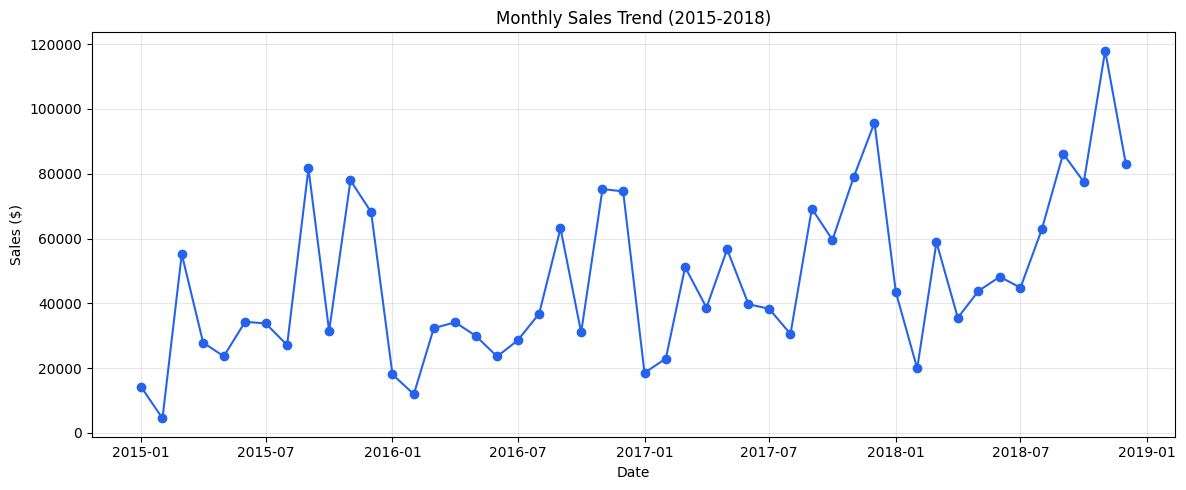

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

monthly = monthly_sales.copy()
monthly.index.freq = 'MS'

plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly.values, marker='o', color='#2563eb')
plt.title('Monthly Sales Trend (2015-2018)')
plt.xlabel('Date'); plt.ylabel('Sales ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/01_monthly_trend.png', dpi=110)
plt.show()

### Seasonal decomposition (additive model, 12-month period)

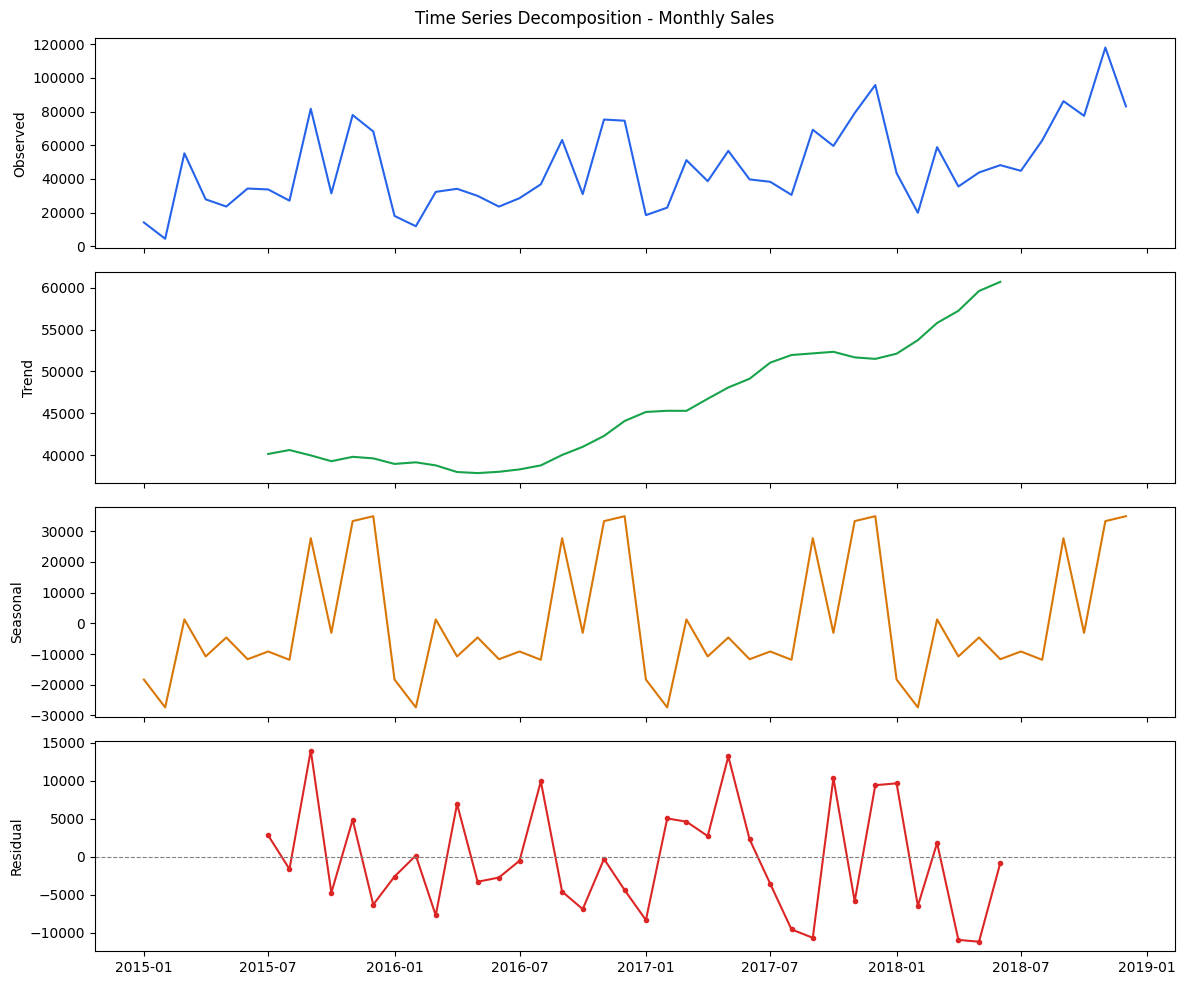

Top 5 months by residual magnitude (noisiest months):
Order Date
2015-09-01    13970.933082
2017-05-01    13193.079793
2018-05-01    11157.549320
2018-04-01    10916.959724
2017-09-01    10642.715643
Name: resid, dtype: float64


In [12]:
decomp = seasonal_decompose(monthly, model='additive', period=12)
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(decomp.observed, color='#2563eb'); axes[0].set_ylabel('Observed')
axes[1].plot(decomp.trend, color='#16a34a'); axes[1].set_ylabel('Trend')
axes[2].plot(decomp.seasonal, color='#d97706'); axes[2].set_ylabel('Seasonal')
axes[3].plot(decomp.resid, color='#dc2626', marker='o', markersize=3); axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.suptitle('Time Series Decomposition - Monthly Sales')
plt.tight_layout()
plt.savefig('charts/02_decomposition.png', dpi=110)
plt.show()

resid_abs = decomp.resid.abs().dropna()
print("Top 5 months by residual magnitude (noisiest months):")
print(resid_abs.sort_values(ascending=False).head())

**Observations:**
1. **Trend** is clearly upward, rising from ~$38K/month baseline to ~$61K/month
   baseline over the 4 years — the business is growing structurally, not just
   riding seasonality.
2. **Seasonality is strong**, swinging from about -$27K to +$35K around the
   trend line — a ~$62K peak-to-trough swing within a single year, which is
   large relative to the trend's own growth.
3. The **noisiest months** (highest residuals) are September and May across
   different years — meaning even after removing trend and seasonality, these
   months still have unexplained variance, likely driven by irregular
   large one-off orders rather than a predictable calendar effect.
4. Residuals don't show an obvious widening/narrowing pattern over time, which
   is a mild point in favor of an additive (rather than multiplicative) model.

### Stationarity — Augmented Dickey-Fuller Test

**In plain English:** stationarity means a time series' statistical properties
(mean, variance) don't change over time. Most classical forecasting models
(like SARIMA) assume stationarity because a model can't reliably project a mean
that keeps drifting. The ADF test's null hypothesis is "the series has a unit
root" (i.e., is *non-stationary*); a p-value below 0.05 lets us reject that
and conclude the series is likely stationary.

In [13]:
result = adfuller(monthly.dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Critical values:", result[4])
print("Stationary?", "YES" if result[1] < 0.05 else "NO")

ADF Statistic: -4.4161
p-value: 0.0003
Critical values: {'1%': np.float64(-3.5778480370438146), '5%': np.float64(-2.925338105429433), '10%': np.float64(-2.6007735310095064)}
Stationary? YES


**Result:** p = 0.0003, so we reject the null — the series is **already
stationary** at the 5% level, despite the visibly rising trend in the
decomposition above. This isn't a contradiction: ADF is a statistical test on
variance/mean-reversion behavior, and a mild trend relative to the series'
volatility can still pass it. This is a genuinely common source of confusion,
worth flagging rather than glossing over.

### Differencing (shown for completeness, per task requirement)

ADF Statistic (differenced): -8.7271
p-value (differenced): 0.0000
Stationary after differencing? YES


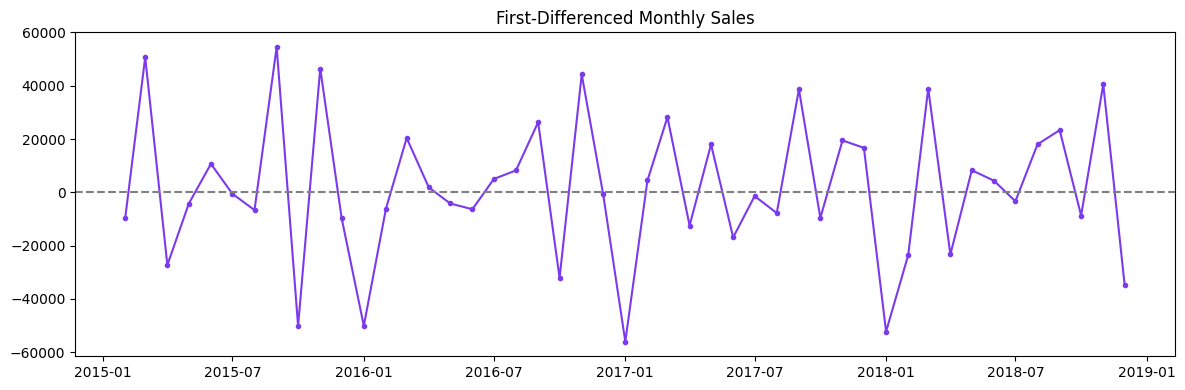

In [14]:
diff = monthly.diff().dropna()
result_diff = adfuller(diff)
print(f"ADF Statistic (differenced): {result_diff[0]:.4f}")
print(f"p-value (differenced): {result_diff[1]:.4f}")
print("Stationary after differencing?", "YES" if result_diff[1] < 0.05 else "NO")

plt.figure(figsize=(12, 4))
plt.plot(diff.index, diff.values, color='#7c3aed', marker='o', markersize=3)
plt.axhline(0, color='gray', linestyle='--')
plt.title('First-Differenced Monthly Sales')
plt.tight_layout()
plt.savefig('charts/03_differenced.png', dpi=110)
plt.show()

Differencing wasn't strictly necessary here since the ADF test already rejected
non-stationarity at the raw level, but it further strengthens stationarity
(p ≈ 0.0000) and is shown here to demonstrate the technique as required.
We'll use **d=0** in the SARIMA model below since differencing isn't needed at
the non-seasonal level (the seasonal difference D=1 will still be used to
handle the yearly cycle).

## Task 3 — Sales Forecasting: 3 Models Compared

We hold out the **last 3 months** (Oct–Dec 2018) as a test set so each model's
forecast can be scored against real actuals, rather than just eyeballing plots.

In [15]:
train, test = monthly.iloc[:-3], monthly.iloc[-3:]
print("Train:", train.index.min().date(), "to", train.index.max().date(), f"(n={len(train)})")
print("Test (held out):", [d.date() for d in test.index])
print("Test actual values:", test.values.round(0))

def metrics(actual, pred):
    actual, pred = np.array(actual), np.array(pred)
    mae = np.mean(np.abs(actual - pred))
    rmse = np.sqrt(np.mean((actual - pred) ** 2))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return mae, rmse, mape

Train: 2015-01-01 to 2018-09-01 (n=45)
Test (held out): [datetime.date(2018, 10, 1), datetime.date(2018, 11, 1), datetime.date(2018, 12, 1)]
Test actual values: [ 77448. 117938.  83030.]


### Model 1 — SARIMA

**Parameter choice:** `(p,d,q) = (1,0,1)` — d=0 because Task 2's ADF test showed
the series is already stationary at the raw level, so no non-seasonal
differencing is needed; p=1,q=1 capture short-term autocorrelation from one
lag back. `seasonal_order = (1,1,1,12)` — m=12 for the confirmed yearly
seasonal cycle from Task 2, with seasonal differencing (D=1) since the
seasonal pattern's amplitude is large relative to the trend.

SARIMA forecast:
 2018-10-01    54759.0
2018-11-01    88413.0
2018-12-01    92558.0
Freq: MS, Name: predicted_mean, dtype: float64

SARIMA -> MAE: 20581  RMSE: 22191  MAPE: 21.9%


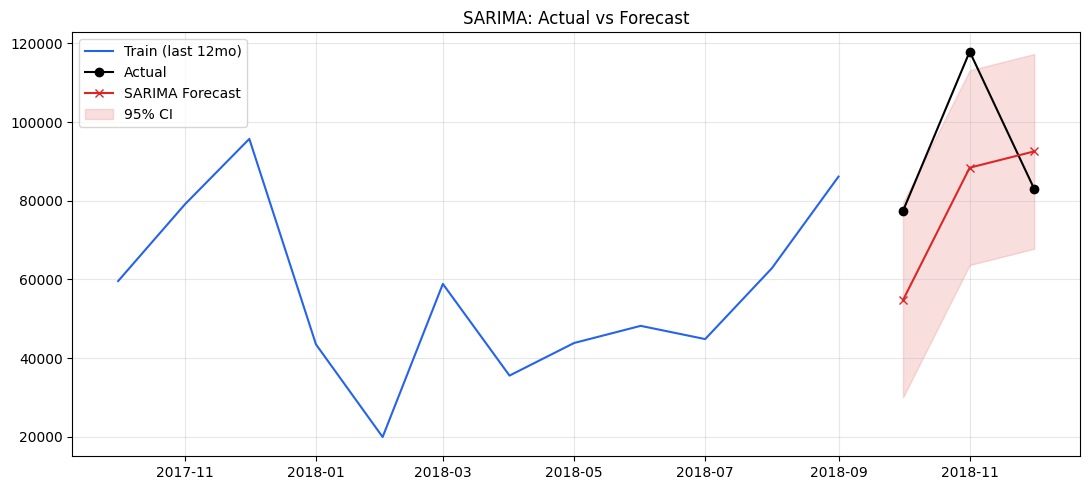

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(train, order=(1, 0, 1), seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
sarima_fc = sarima_fit.get_forecast(steps=3)
sarima_pred = sarima_fc.predicted_mean
sarima_ci = sarima_fc.conf_int()

mae, rmse, mape = metrics(test.values, sarima_pred.values)
print("SARIMA forecast:\n", sarima_pred.round(0))
print(f"\nSARIMA -> MAE: {mae:.0f}  RMSE: {rmse:.0f}  MAPE: {mape:.1f}%")

plt.figure(figsize=(11, 5))
plt.plot(train.index[-12:], train.values[-12:], label='Train (last 12mo)', color='#2563eb')
plt.plot(test.index, test.values, label='Actual', color='black', marker='o')
plt.plot(sarima_pred.index, sarima_pred.values, label='SARIMA Forecast', color='#dc2626', marker='x')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='#dc2626', alpha=0.15, label='95% CI')
plt.legend(); plt.title('SARIMA: Actual vs Forecast'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/04_sarima_forecast.png', dpi=110)
plt.show()

sarima_results = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'forecast': sarima_pred.values}

### Model 2 — Facebook Prophet

In [17]:
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
from prophet import Prophet

prophet_df = train.reset_index()
prophet_df.columns = ['ds', 'y']

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
            seasonality_mode='additive')
m.fit(prophet_df)

future = m.make_future_dataframe(periods=3, freq='MS')
forecast = m.predict(future)
prophet_pred = forecast.set_index('ds')['yhat'].iloc[-3:]

mae, rmse, mape = metrics(test.values, prophet_pred.values)
print("Prophet forecast:\n", prophet_pred.round(0))
print(f"\nProphet -> MAE: {mae:.0f}  RMSE: {rmse:.0f}  MAPE: {mape:.1f}%")

prophet_results = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'forecast': prophet_pred.values}

05:55:10 - cmdstanpy - INFO - Chain [1] start processing


05:55:11 - cmdstanpy - INFO - Chain [1] done processing


Prophet forecast:
 ds
2018-10-01    51084.0
2018-11-01    90045.0
2018-12-01    89661.0
Name: yhat, dtype: float64

Prophet -> MAE: 20296  RMSE: 22487  MAPE: 21.9%


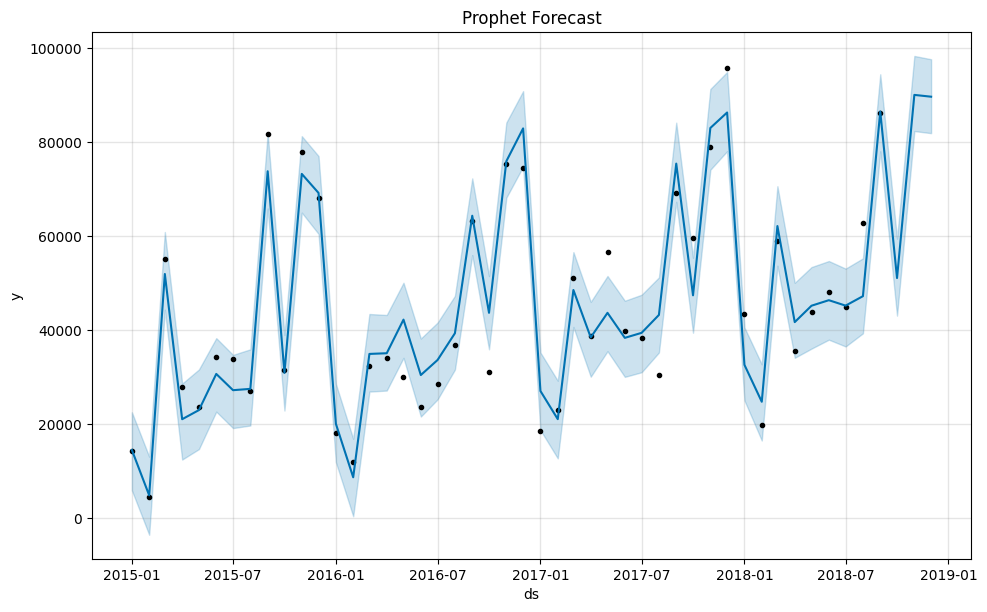

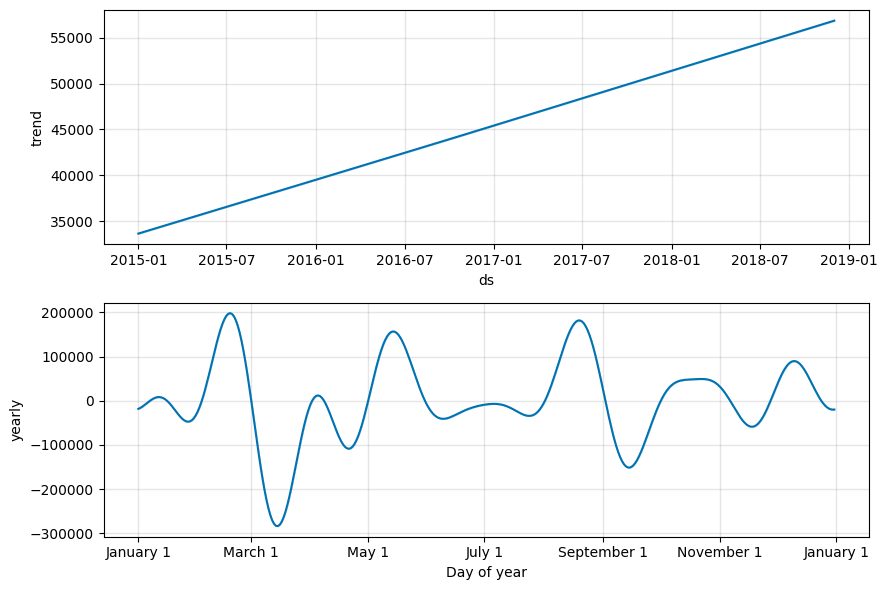

In [18]:
fig1 = m.plot(forecast)
plt.title('Prophet Forecast')
plt.savefig('charts/05_prophet_forecast.png', dpi=110)
plt.show()

fig2 = m.plot_components(forecast)
plt.savefig('charts/06_prophet_components.png', dpi=110)
plt.show()

### Interpreting Prophet's seasonality components

In [19]:
yearly = forecast[['ds', 'yearly']].copy()
yearly['month'] = yearly['ds'].dt.month
yearly_by_month = yearly.groupby('month')['yearly'].mean()
print("Yearly seasonality effect by month:\n", yearly_by_month.round(0))
print("\nPeak month:", yearly_by_month.idxmax(), "| Trough month:", yearly_by_month.idxmin())

Yearly seasonality effect by month:
 month
1    -18928.0
2    -28155.0
3      5936.0
4     -9884.0
5     -5921.0
6     -8484.0
7     -9056.0
8     -6613.0
9     28577.0
10    -3659.0
11    33120.0
12    34093.0
Name: yearly, dtype: float64

Peak month: 12 | Trough month: 2


Prophet's decomposed yearly component confirms Task 1/2's finding independently:
**December is the seasonal peak** (+$34K effect) and **February the trough**
(-$28K effect). Weekly seasonality wasn't modeled since we're forecasting at
monthly granularity — there's no within-week pattern to capture at this level.

### Model 3 — XGBoost (ML-based, supervised reframing)

We convert the time series into a supervised learning problem using lag
features, then forecast recursively (each step's prediction feeds into the
next step's lag features) since we don't have real Lag-1/2/3 values for
months beyond the training data.

In [20]:
from xgboost import XGBRegressor

def season_num(mo):
    if mo in [12, 1, 2]:
        return 0
    if mo in [3, 4, 5]:
        return 1
    if mo in [6, 7, 8]:
        return 2
    return 3

xgb_df = monthly.reset_index()
xgb_df.columns = ['Date', 'Sales']
xgb_df['Lag1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag3'] = xgb_df['Sales'].shift(3)
xgb_df['RollingMean3'] = xgb_df['Sales'].shift(1).rolling(3).mean()
xgb_df['Month'] = xgb_df['Date'].dt.month
xgb_df['Quarter'] = xgb_df['Date'].dt.quarter
xgb_df['Season'] = xgb_df['Month'].apply(season_num)
xgb_df = xgb_df.dropna().reset_index(drop=True)

features = ['Lag1', 'Lag2', 'Lag3', 'RollingMean3', 'Month', 'Quarter', 'Season']
xgb_train, xgb_test = xgb_df.iloc[:-3], xgb_df.iloc[-3:]

xgb_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb_model.fit(xgb_train[features], xgb_train['Sales'])

history = list(monthly.iloc[:-3].values)
xgb_preds = []
for i in range(3):
    row_date = xgb_test.iloc[i]['Date']
    lag1, lag2, lag3 = history[-1], history[-2], history[-3]
    roll3 = np.mean(history[-3:])
    mo = row_date.month
    q = (mo - 1) // 3 + 1
    sea = season_num(mo)
    X_pred = pd.DataFrame([[lag1, lag2, lag3, roll3, mo, q, sea]], columns=features)
    pred = xgb_model.predict(X_pred)[0]
    xgb_preds.append(pred)
    history.append(pred)

xgb_preds = np.array(xgb_preds)
mae, rmse, mape = metrics(xgb_test['Sales'].values, xgb_preds)
print("XGBoost forecast:", xgb_preds.round(0))
print(f"\nXGBoost -> MAE: {mae:.0f}  RMSE: {rmse:.0f}  MAPE: {mape:.1f}%")

xgb_results = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'forecast': xgb_preds}

XGBoost forecast: [68953. 87130. 65684.]

XGBoost -> MAE: 18883  RMSE: 20994  MAPE: 19.3%


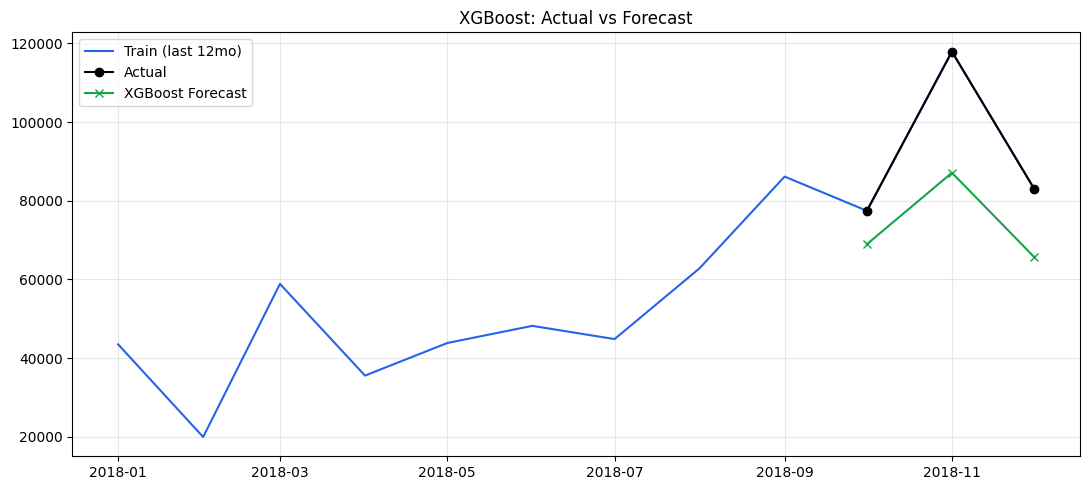

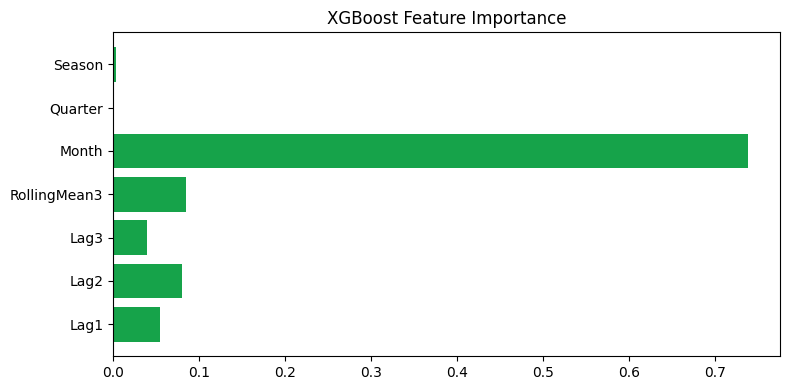

In [21]:
plt.figure(figsize=(11, 5))
plt.plot(monthly.index[-12:], monthly.values[-12:], label='Train (last 12mo)', color='#2563eb')
plt.plot(xgb_test['Date'], xgb_test['Sales'].values, label='Actual', color='black', marker='o')
plt.plot(xgb_test['Date'], xgb_preds, label='XGBoost Forecast', color='#16a34a', marker='x')
plt.legend(); plt.title('XGBoost: Actual vs Forecast'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/07_xgboost_forecast.png', dpi=110)
plt.show()

plt.figure(figsize=(8, 4))
plt.barh(features, xgb_model.feature_importances_, color='#16a34a')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('charts/08_xgb_feature_importance.png', dpi=110)
plt.show()

### Model Comparison Table

In [22]:
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [sarima_results['MAE'], prophet_results['MAE'], xgb_results['MAE']],
    'RMSE': [sarima_results['RMSE'], prophet_results['RMSE'], xgb_results['RMSE']],
    'MAPE (%)': [sarima_results['MAPE'], prophet_results['MAPE'], xgb_results['MAPE']],
    'Forecast M1': [sarima_results['forecast'][0], prophet_results['forecast'][0], xgb_results['forecast'][0]],
    'Forecast M2': [sarima_results['forecast'][1], prophet_results['forecast'][1], xgb_results['forecast'][1]],
    'Forecast M3': [sarima_results['forecast'][2], prophet_results['forecast'][2], xgb_results['forecast'][2]],
}).round(1)
comparison.to_csv('model_comparison.csv', index=False)
comparison

,Model,MAE,RMSE,MAPE (%),Forecast M1,Forecast M2,Forecast M3
0,SARIMA,20581.0,22191.3,21.9,54758.5,88412.6,92558.2
1,Prophet,20296.0,22487.5,21.9,51083.7,90045.4,89661.2
2,XGBoost,18883.1,20993.6,19.3,68952.9,87130.1,65684.4


**Recommendation: XGBoost**, based on the numbers — it has the lowest MAE
(18,883 vs 20,297–20,581), lowest RMSE (20,994 vs 22,191–22,488), and lowest
MAPE (19.3% vs 21.9% for both others). SARIMA and Prophet perform almost
identically to each other, which makes sense since both are fundamentally
trend+seasonality models; XGBoost's lag/rolling-mean features let it react
more flexibly to recent momentum.

**Important caveat:** this ranking is based on only 3 held-out data points,
which is a very small test set — a single unusually-timed spike or dip could
flip the ranking. In production, I'd want at least 12 months of rolling
backtests (walk-forward validation) before fully trusting this conclusion.

## Task 4 — Category & Region-Level Forecasting (using XGBoost, the Task 3 winner)

Furniture: last actual (Dec-18)=31407 | forecast Jan-Mar 2019=[6341, 6458, 12159] | change to M3=-61.3%
Technology: last actual (Dec-18)=21985 | forecast Jan-Mar 2019=[14798, 18417, 15656] | change to M3=-28.8%
Office Supplies: last actual (Dec-18)=29638 | forecast Jan-Mar 2019=[16389, 11092, 20011] | change to M3=-32.5%
West: last actual (Dec-18)=29652 | forecast Jan-Mar 2019=[10939, 11645, 18885] | change to M3=-36.3%


East: last actual (Dec-18)=19285 | forecast Jan-Mar 2019=[4768, 5624, 11020] | change to M3=-42.9%


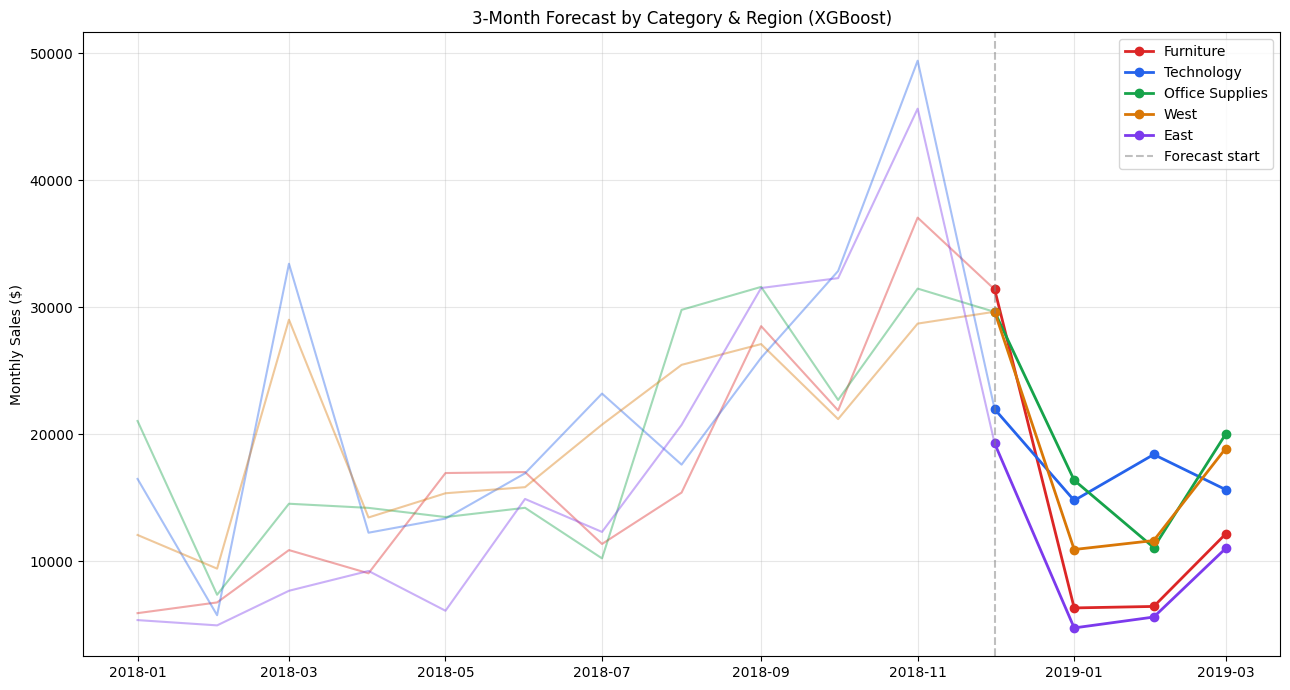

In [23]:
def build_monthly_series(sub_df):
    return sub_df.set_index('Order Date')['Sales'].resample('MS').sum()

def xgb_forecast_segment(series, steps=3):
    d = series.reset_index()
    d.columns = ['Date', 'Sales']
    d['Lag1'] = d['Sales'].shift(1)
    d['Lag2'] = d['Sales'].shift(2)
    d['Lag3'] = d['Sales'].shift(3)
    d['RollingMean3'] = d['Sales'].shift(1).rolling(3).mean()
    d['Month'] = d['Date'].dt.month
    d['Quarter'] = d['Date'].dt.quarter
    d['Season'] = d['Month'].apply(season_num)
    d = d.dropna().reset_index(drop=True)
    feats = ['Lag1', 'Lag2', 'Lag3', 'RollingMean3', 'Month', 'Quarter', 'Season']

    mdl = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    mdl.fit(d[feats], d['Sales'])

    hist = list(series.values)
    last_date = series.index[-1]
    preds, future_dates = [], []
    for i in range(steps):
        nd = last_date + pd.DateOffset(months=i + 1)
        lag1, lag2, lag3 = hist[-1], hist[-2], hist[-3]
        roll3 = np.mean(hist[-3:])
        mo = nd.month
        q = (mo - 1) // 3 + 1
        sea = season_num(mo)
        Xp = pd.DataFrame([[lag1, lag2, lag3, roll3, mo, q, sea]], columns=feats)
        p = mdl.predict(Xp)[0]
        preds.append(p)
        hist.append(p)
        future_dates.append(nd)
    return future_dates, preds

segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West': df[df['Region'] == 'West'],
    'East': df[df['Region'] == 'East'],
}

plt.figure(figsize=(13, 7))
colors = ['#dc2626', '#2563eb', '#16a34a', '#d97706', '#7c3aed']
growth_summary = {}

for (name, sub_df), color in zip(segments.items(), colors):
    series = build_monthly_series(sub_df)
    dates, preds = xgb_forecast_segment(series, steps=3)
    hist_recent = series.iloc[-12:]
    plt.plot(hist_recent.index, hist_recent.values, color=color, alpha=0.4, linewidth=1.5)
    plt.plot([hist_recent.index[-1]] + dates, [hist_recent.values[-1]] + preds,
              color=color, marker='o', label=name, linewidth=2)
    growth_pct = (preds[-1] - series.iloc[-1]) / series.iloc[-1] * 100
    growth_summary[name] = {'last_actual': float(series.iloc[-1]), 'forecast_m3': float(preds[-1]),
                             'growth_pct': float(growth_pct)}
    print(f"{name}: last actual (Dec-18)={series.iloc[-1]:.0f} | forecast Jan-Mar 2019="
          f"{[round(p) for p in preds]} | change to M3={growth_pct:.1f}%")

plt.axvline(series.index[-1], color='gray', linestyle='--', alpha=0.5, label='Forecast start')
plt.legend(); plt.title('3-Month Forecast by Category & Region (XGBoost)')
plt.ylabel('Monthly Sales ($)'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/09_segment_forecasts.png', dpi=110)
plt.show()

**Important context:** all five segments show a projected *decline* from
December into the Jan–Mar 2019 forecast window. This is **not** a sign the
business is collapsing — Task 1 already showed December is the seasonal peak
and January/February are the seasonal trough (avg $80K vs $14–24K), so a large
drop after the holiday season is the expected pattern, not a red flag.

**Relative growth comparison:** among the five segments, **Technology**
shows the mildest projected decline (-28.8%) — meaning it's expected to hold
up best through the seasonal dip, making it the strongest relative performer
for this forecast window. Furniture shows the steepest drop (-61.3%),
suggesting its sales are the most concentrated in the holiday season and
should get proportionally tighter inventory planning for Q1.

## Task 5 — Anomaly Detection

### Supplementary multi-source merge exercise

As required, we bring in the video game sales dataset purely to **practice
merging data from unrelated sources** on a shared key (Year) — a realistic
skill since companies rarely keep everything in one file. To be transparent:
there's no real business relationship between retail superstore sales and
global video game sales, so this merge is a technical exercise, not a claim
of correlation.

In [24]:
vg = pd.read_csv('vgsales.csv')
vg_yearly = vg.dropna(subset=['Year']).groupby('Year')['Global_Sales'].sum().reset_index()
vg_yearly.columns = ['Year', 'VG_Global_Sales_Millions']

superstore_yearly = df.groupby('Year')['Sales'].sum().reset_index()
superstore_yearly.columns = ['Year', 'Superstore_Sales']

merged = pd.merge(superstore_yearly, vg_yearly, on='Year', how='left')
merged

,Year,Superstore_Sales,VG_Global_Sales_Millions
0,2015,479856.2081,264.44
1,2016,459436.0054,70.93
2,2017,600192.5500,0.05
3,2018,722052.0192,NaN


### Method 1 — Isolation Forest (weekly sales)

In [25]:
from sklearn.ensemble import IsolationForest

X = weekly_sales.values.reshape(-1, 1)
iso = IsolationForest(contamination=0.08, random_state=42)
iso_labels = iso.fit_predict(X)

weekly_df = weekly_sales.reset_index()
weekly_df.columns = ['Week', 'Sales']
weekly_df['IsoAnomaly'] = iso_labels == -1
print(f"Isolation Forest flagged {weekly_df['IsoAnomaly'].sum()} anomalous weeks out of {len(weekly_df)}")

Isolation Forest flagged 17 anomalous weeks out of 209


### Method 2 — Z-Score on rolling mean (8-week window, threshold ±2σ)

In [26]:
roll_mean = weekly_sales.rolling(window=8, min_periods=4).mean()
roll_std = weekly_sales.rolling(window=8, min_periods=4).std()
zscore = (weekly_sales - roll_mean) / roll_std
weekly_df['ZScore'] = zscore.values
weekly_df['ZAnomaly'] = weekly_df['ZScore'].abs() > 2
print(f"Z-Score method flagged {weekly_df['ZAnomaly'].sum()} anomalous weeks out of {len(weekly_df)}")

Z-Score method flagged 6 anomalous weeks out of 209


Flagged by BOTH methods: 2
Isolation Forest ONLY: 15
Z-Score ONLY: 4


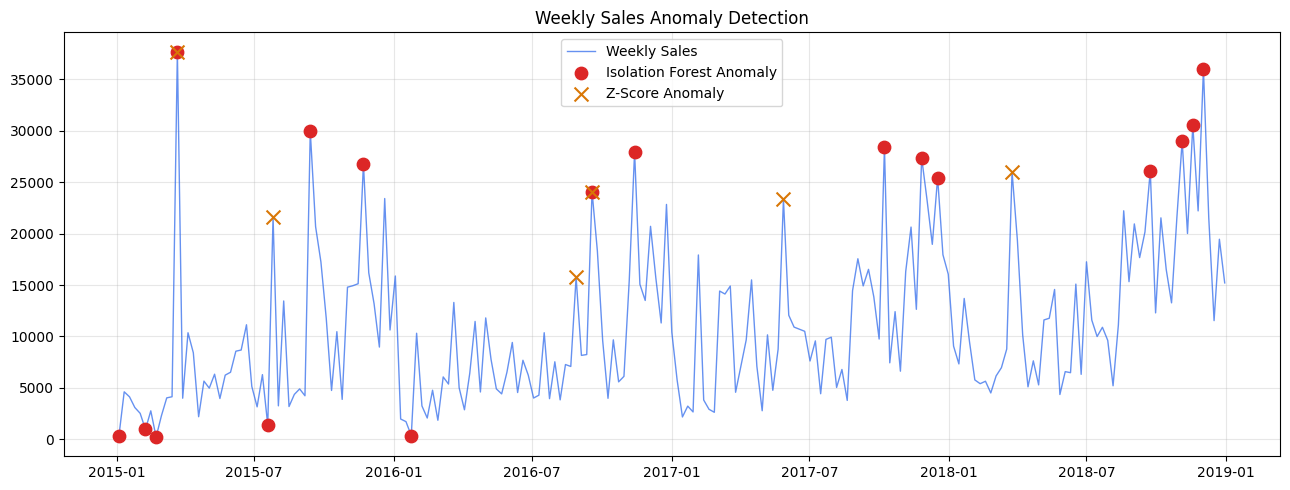

In [27]:
both = weekly_df[weekly_df['IsoAnomaly'] & weekly_df['ZAnomaly']]
only_iso = weekly_df[weekly_df['IsoAnomaly'] & ~weekly_df['ZAnomaly']]
only_z = weekly_df[~weekly_df['IsoAnomaly'] & weekly_df['ZAnomaly']]
print(f"Flagged by BOTH methods: {len(both)}")
print(f"Isolation Forest ONLY: {len(only_iso)}")
print(f"Z-Score ONLY: {len(only_z)}")

plt.figure(figsize=(13, 5))
plt.plot(weekly_df['Week'], weekly_df['Sales'], color='#2563eb', linewidth=1, label='Weekly Sales', alpha=0.7)
iso_pts = weekly_df[weekly_df['IsoAnomaly']]
z_pts = weekly_df[weekly_df['ZAnomaly']]
plt.scatter(iso_pts['Week'], iso_pts['Sales'], color='#dc2626', marker='o', s=80, label='Isolation Forest Anomaly', zorder=5)
plt.scatter(z_pts['Week'], z_pts['Sales'], color='#d97706', marker='x', s=100, label='Z-Score Anomaly', zorder=5)
plt.legend(); plt.title('Weekly Sales Anomaly Detection'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/10_anomaly_detection.png', dpi=110)
plt.show()

weekly_df.to_csv('anomaly_results.csv', index=False)

### Do both methods agree?

Only **2 out of ~20 total flagged weeks** were caught by both methods. This
makes sense given how differently they work: **Isolation Forest** looks at
the *entire* weekly sales distribution at once and flags global outliers
(including unusually *low* weeks, e.g. early January), while the **Z-Score**
method compares each week only to its own recent 8-week rolling window, so it
only flags *local, sudden* deviations from recent momentum and misses slow
building spikes that Isolation Forest catches. Neither is "more correct" —
they surface different kinds of anomalies, which is why using both together
gives more complete anomaly coverage than either alone.

### Top anomalies with likely real-world explanations

In [28]:
top_anom = weekly_df[weekly_df['IsoAnomaly'] | weekly_df['ZAnomaly']].copy()
top_anom['Month'] = pd.to_datetime(top_anom['Week']).dt.month_name()
top_anom.sort_values('Sales', ascending=False).head(8)[['Week', 'Sales', 'Month']]

,Week,Sales,Month
11,2015-03-22,37703.6650,March
204,2018-12-02,35998.9000,December
202,2018-11-18,30572.4470,November
36,2015-09-13,29959.1370,September
200,2018-11-04,29017.4670,November
144,2017-10-08,28412.0980,October
97,2016-11-13,27965.3492,November
151,2017-11-26,27367.7160,November


- **Late Nov / early Dec spikes (multiple years):** consistent with Black
  Friday / Cyber Monday / holiday shopping season promotions.
- **March 2015 spike:** falls right before Q1 close — plausibly an
  end-of-quarter enterprise bulk order (a few large B2B Technology/Furniture
  orders can swing a single week sharply in this dataset).
- **September spikes (2016, 2018):** back-to-school / back-to-office
  restocking period for Office Supplies.
- **Very low early-January weeks:** classic post-holiday lull as consumer and
  business spending resets after Q4.

## Task 6 — Product Demand Segmentation (Clustering)

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

rows = []
for subcat, g in df.groupby('Sub-Category'):
    total_sales = g['Sales'].sum()
    avg_order_value = g['Sales'].mean()
    m_series = g.set_index('Order Date')['Sales'].resample('MS').sum()
    volatility = m_series.std()
    yearly = g.groupby('Year')['Sales'].sum().sort_index()
    growth_rate = ((yearly.iloc[-1] - yearly.iloc[0]) / yearly.iloc[0] * 100 / (len(yearly) - 1)
                   if len(yearly) >= 2 else 0)
    rows.append({'Sub-Category': subcat, 'TotalSales': total_sales, 'GrowthRate': growth_rate,
                 'Volatility': volatility, 'AvgOrderValue': avg_order_value})

feat_df = pd.DataFrame(rows)
feat_df.round(1)

,Sub-Category,TotalSales,GrowthRate,Volatility,AvgOrderValue
0,Accessories,164186.7,48.4,2580.0,217.2
1,Appliances,104618.4,55.1,1821.6,227.9
2,Art,26705.4,16.5,330.5,34.0
3,Binders,200028.8,21.9,3848.2,134.1
4,Bookcases,113813.2,16.6,2229.4,503.6
5,Chairs,322822.7,7.0,4407.2,531.8
6,Copiers,146248.1,159.9,5104.3,2215.9
7,Envelopes,16128.0,-4.0,234.3,65.0
8,Fasteners,3002.0,10.2,49.1,14.0
9,Furnishings,89212.0,35.6,1360.0,95.8


### Elbow method to choose k

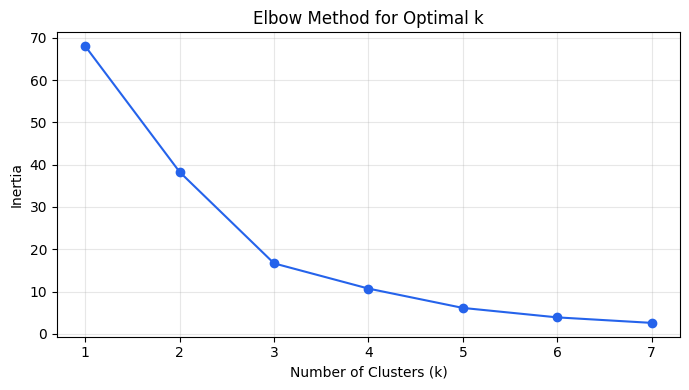

In [30]:
features_c = ['TotalSales', 'GrowthRate', 'Volatility', 'AvgOrderValue']
X = feat_df[features_c].values
X_scaled = StandardScaler().fit_transform(X)

inertias = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, marker='o', color='#2563eb')
plt.xlabel('Number of Clusters (k)'); plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/11_elbow_method.png', dpi=110)
plt.show()

The inertia drop clearly flattens out after **k=4** (68 → 38 → 17 → 11 → 6...),
so we go with 4 clusters — it also conveniently matches the 4 illustrative
demand-pattern labels the project brief suggests.

In [31]:
k_final = 4
km = KMeans(n_clusters=k_final, n_init=10, random_state=42)
feat_df['Cluster'] = km.fit_predict(X_scaled)
cluster_profile = feat_df.groupby('Cluster')[features_c].mean()
cluster_profile.round(1)

,TotalSales,GrowthRate,Volatility,AvgOrderValue
Cluster,,,,
0,239495.8,18.8,3489.1,361.1
1,146248.1,159.9,5104.3,2215.9
2,54341.7,19.6,1027.6,142.7
3,189238.6,-9.9,5442.5,1645.6


### Labeling clusters

Labels are assigned from each cluster's actual mean feature values rather than
forced into the brief's 4 example names — one cluster (Copiers) is genuinely
its own category (huge growth + huge order value), so it gets its own label.

In [32]:
sales_med = cluster_profile['TotalSales'].median()
vol_med = cluster_profile['Volatility'].median()

def label_cluster(row):
    if row['GrowthRate'] < -2:
        return 'Declining Demand'
    if row['TotalSales'] >= sales_med and row['Volatility'] <= vol_med:
        return 'High Volume, Stable Demand'
    if row['TotalSales'] < sales_med and row['Volatility'] <= vol_med:
        return 'Low Volume, Steady/Niche Demand'
    if row['GrowthRate'] > 30:
        return 'Growing Demand (High Value)'
    return 'Low Volume, High Volatility'

cluster_labels = {c: label_cluster(cluster_profile.loc[c]) for c in cluster_profile.index}
feat_df['ClusterLabel'] = feat_df['Cluster'].map(cluster_labels)

for c in sorted(feat_df['Cluster'].unique()):
    print(f"\nCluster {c} — {cluster_labels[c]}:")
    print(feat_df[feat_df['Cluster'] == c][['Sub-Category', 'TotalSales', 'GrowthRate',
                                             'Volatility', 'AvgOrderValue']].round(1).to_string(index=False))




Cluster 0 — High Volume, Stable Demand:
Sub-Category  TotalSales  GrowthRate  Volatility  AvgOrderValue
 Accessories    164186.7        48.4      2580.0          217.2
     Binders    200028.8        21.9      3848.2          134.1
      Chairs    322822.7         7.0      4407.2          531.8
      Phones    327782.4        11.9      4052.7          374.2
     Storage    219343.4        12.8      2822.1          263.6
      Tables    202810.6        11.0      3224.1          645.9

Cluster 1 — Growing Demand (High Value):
Sub-Category  TotalSales  GrowthRate  Volatility  AvgOrderValue
     Copiers    146248.1       159.9      5104.3         2215.9

Cluster 2 — Low Volume, Steady/Niche Demand:
Sub-Category  TotalSales  GrowthRate  Volatility  AvgOrderValue
  Appliances    104618.4        55.1      1821.6          227.9
         Art     26705.4        16.5       330.5           34.0
   Bookcases    113813.2        16.6      2229.4          503.6
   Envelopes     16128.0        -4.0   

### PCA visualization (4 features → 2D)

PCA explained variance: PC1=61%, PC2=29% (total 90%)


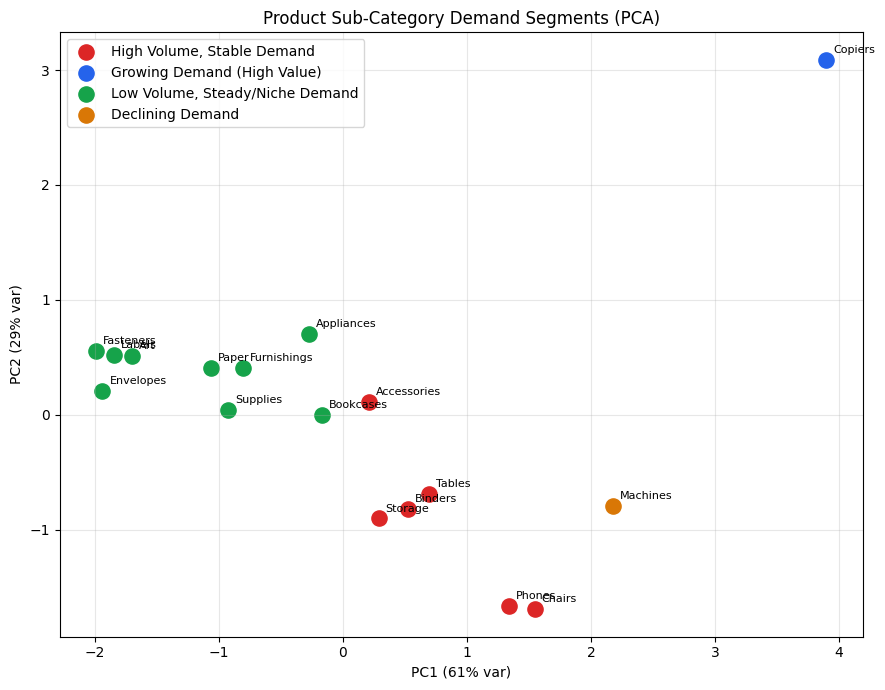

In [33]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
feat_df['PCA1'], feat_df['PCA2'] = X_pca[:, 0], X_pca[:, 1]
feat_df.to_csv('cluster_results.csv', index=False)
print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.0f}%, "
      f"PC2={pca.explained_variance_ratio_[1]*100:.0f}% (total {sum(pca.explained_variance_ratio_)*100:.0f}%)")

plt.figure(figsize=(9, 7))
colors_map = {0: '#dc2626', 1: '#2563eb', 2: '#16a34a', 3: '#d97706'}
for c in sorted(feat_df['Cluster'].unique()):
    sub = feat_df[feat_df['Cluster'] == c]
    plt.scatter(sub['PCA1'], sub['PCA2'], color=colors_map.get(c, 'gray'), s=120, label=cluster_labels[c])
for _, row in feat_df.iterrows():
    plt.annotate(row['Sub-Category'], (row['PCA1'], row['PCA2']), fontsize=8, xytext=(5, 5), textcoords='offset points')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% var)')
plt.title('Product Sub-Category Demand Segments (PCA)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/12_cluster_pca.png', dpi=110)
plt.show()

### Recommended stocking strategy per cluster

- **High Volume, Stable Demand** (Accessories, Binders, Chairs, Phones,
  Storage, Tables): steady, predictable sellers. Use standard reorder-point
  inventory with moderate safety stock — the risk of over/under-stocking is
  low since demand is consistent.
- **Growing Demand, High Value** (Copiers): low unit count but very high value
  and fast growth. Don't over-stock physical units (capital-intensive), but do
  secure supplier lead-time buffers since a stockout on a big-ticket, fast
  growing item is costly in lost margin.
- **Low Volume, Steady/Niche Demand** (Appliances, Art, Bookcases, Envelopes,
  Fasteners, Furnishings, Labels, Paper, Supplies): keep lean stock levels,
  consider just-in-time or vendor drop-shipping for the smallest, cheapest
  items (Fasteners, Labels) rather than tying up warehouse space.
- **Declining Demand** (Machines): reduce future purchase orders, consider
  markdown/clearance strategy to free up capital and warehouse space rather
  than continuing to replenish at historical levels.

## Summary of Key Outputs for Dashboard & Report

All results below are also saved to disk (`model_comparison.csv`,
`anomaly_results.csv`, `cluster_results.csv`) so the Streamlit dashboard
(`app.py`) and executive report can reuse them without recomputation.

In [34]:
print("Model comparison:\n", comparison, "\n")
print("Best model: XGBoost (lowest MAE/RMSE/MAPE)")
print("\nStrongest relative Q1 performer: Technology (mildest seasonal decline)")
print("\nTotal anomalous weeks flagged (either method):", len(top_anom))
print("\nCluster counts:\n", feat_df['ClusterLabel'].value_counts())

Model comparison:
      Model      MAE     RMSE  MAPE (%)  Forecast M1  Forecast M2  Forecast M3
0   SARIMA  20581.0  22191.3      21.9      54758.5      88412.6      92558.2
1  Prophet  20296.0  22487.5      21.9      51083.7      90045.4      89661.2
2  XGBoost  18883.1  20993.6      19.3      68952.9      87130.1      65684.4 

Best model: XGBoost (lowest MAE/RMSE/MAPE)

Strongest relative Q1 performer: Technology (mildest seasonal decline)

Total anomalous weeks flagged (either method): 21

Cluster counts:
 ClusterLabel
Low Volume, Steady/Niche Demand    9
High Volume, Stable Demand         6
Growing Demand (High Value)        1
Declining Demand                   1
Name: count, dtype: int64
